## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# W06M1 - Taller Opcional


In [11]:


import numpy as np
from numpy import deg2rad
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, acos, asin,  latex, atan2, pprint, init_printing, Derivative, sqrt, rad, Eq, integrate, lambdify
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting, Point
# Configuración de impresión en formato LaTeX (MathJax)
init_vprinting(use_latex='mathjax')

# Ej1
Derive las ecuaciones de aceleración en coordenadas polares. Identifique los términos en las componentes radial y tangencial.

In [3]:
theta, r = dynamicsymbols('theta r')
t = symbols('t')

N = ReferenceFrame('N')  # Referencia inercial
A = N.orientnew('A', 'Axis', [theta, N.z])

r1 = r*A.x

display(r1.express(N).simplify())

display(r1.diff(t, N).express(N).simplify())


display(r1.diff(t, N).diff(t, N).express(N).simplify())


r⋅cos(θ) n_x + r⋅sin(θ) n_y

(-r⋅sin(θ)⋅θ̇ + cos(θ)⋅ṙ) n_x + (r⋅cos(θ)⋅θ̇ + sin(θ)⋅ṙ) n_y

⎛                        2                          ⎞       ⎛            2     ↪
⎝-r⋅sin(θ)⋅θ̈ - r⋅cos(θ)⋅θ̇  - 2⋅sin(θ)⋅ṙ⋅θ̇ + cos(θ)⋅r̈⎠ n_x + ⎝- r⋅sin(θ)⋅θ̇  + r ↪

↪                                    ⎞    
↪ ⋅cos(θ)⋅θ̈ + sin(θ)⋅r̈ + 2⋅cos(θ)⋅ṙ⋅θ̇⎠ n_y

# Ej2
Una partícula inicia en reposo en el punto O en el instante t=0. La partícula se acelera
con aceleración tangencial constante a_t mientras recorre la ranura en la dirección ccw.
Determine theta y thetadot como funciones del tiempo durante la primera revolución de
la partícula en la ranura

In [4]:
theta = dynamicsymbols('theta')
t, b, a_t, r = symbols('t b a_t r')

N = ReferenceFrame('N')  # Referencia inercial
A = N.orientnew('A', 'Axis', [theta, N.z])

r1 = r*A.x

display(r1.express(N).simplify())

eq_Vel = r1.diff(t, N).express(N).simplify()


eq_Acc = eq_Vel.diff(t, N).express(N).simplify()

display(eq_Vel)
display(eq_Acc.express(A).simplify())

sub = {
    r: b,
    theta: 2*pi,
    theta.diff(t): a_t,
    theta.diff(t, 2): 0,
}

acel_tan = eq_Acc.express(A).simplify().dot(A.y)

display(acel_tan)

eq  = Eq(acel_tan, a_t)

# Luego despejamos para theta e integramos para encontrar theta y thetadot

thetadotdot = solve(eq, theta.diff(t, 2))[0]

display(thetadotdot)

thetadot = integrate(thetadotdot, t)

display(thetadot)

theta = integrate(thetadot, t)

display(theta)

r⋅cos(θ) n_x + r⋅sin(θ) n_y

-r⋅sin(θ)⋅θ̇ n_x + r⋅cos(θ)⋅θ̇ n_y

    2              
-r⋅θ̇  a_x + r⋅θ̈ a_y

r⋅θ̈

aₜ
──
r 

aₜ⋅t
────
 r  

    2
aₜ⋅t 
─────
 2⋅r 

# Ej3

In [5]:
theta, l = dynamicsymbols('theta l')
t, r = symbols('t r')

N = ReferenceFrame('N')  # Referencia inercial
A = N.orientnew('A', 'Axis', [theta, N.z])

r1 = l*A.x
r3 = -r*N.y

r2 = -r1-r3

r2.diff(t, N).diff(t, N).express(N).simplify()



⎛                       2                          ⎞       ⎛          2        ↪
⎝l⋅sin(θ)⋅θ̈ + l⋅cos(θ)⋅θ̇  + 2⋅sin(θ)⋅l̇⋅θ̇ - cos(θ)⋅l̈⎠ n_x + ⎝l⋅sin(θ)⋅θ̇  - l⋅co ↪

↪                                 ⎞    
↪ s(θ)⋅θ̈ - sin(θ)⋅l̈ - 2⋅cos(θ)⋅l̇⋅θ̇⎠ n_y

In [6]:
from sympy import symbols, simplify
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame, dot

# variables
b = symbols('b')                       # radio fijo de la circunferencia (constante)
theta = dynamicsymbols('theta')        # theta(t)
r = dynamicsymbols('r')                # r(t) (distancia desde O a P)

# frame inercial
N = ReferenceFrame('N')

# vector posición de P respecto a O, exprimido en N (coordenadas polares en O)
r_vec = r * (theta.cos()*N.x + theta.sin()*N.y)

# vector posición del centro C respecto a O (centro está en y = b)
c_vec = b * N.y

# condición: P está sobre la circunferencia de radio b centrada en C
# => distancia |P - C|^2 == b^2
closure = (r_vec - c_vec).dot(r_vec - c_vec) - b**2

# simplificamos la condición escalar
closure_simpl = simplify(closure)
print('closure:', closure_simpl)
# debería dar algo como r**2 - 2*b*r*sin(theta)

# Resolver la ecuación algebraicamente para r (quitando r=0 trivial)
# closure_simpl = r*(r - 2*b*sin(theta))  => r = 0 ó r = 2*b*sin(theta)
# aquí solo extraemos la relación no-trivial r = 2*b*sin(theta)
r_expr = simplify(2*b*theta.sin())
print('r(theta) =', r_expr)

# derivada temporal de r_expr -> r_dot
r_dot_expr = r_expr.diff()
# sympy reconoce derivadas de theta como theta.diff()
print('r_dot =', simplify(r_dot_expr))
# resultado: 2*b*cos(theta)*theta.diff()


AttributeError: 'theta' object has no attribute 'cos'

# Ej4

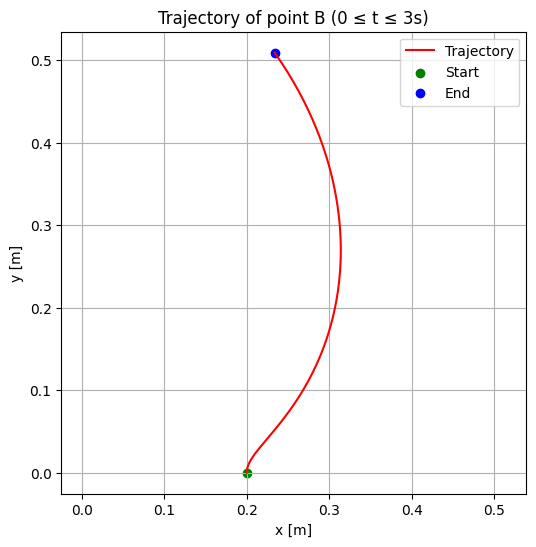

In [17]:
t = symbols('t')
N = ReferenceFrame('N')

theta_expr = 0.2*t + 0.02*t**3
r_expr = 0.2 + 0.04*t**2

A = N.orientnew('A', 'Axis', [theta_expr, N.z])

rB = r_expr * A.x

x_expr = rB.express(N).dot(N.x).simplify()
y_expr = rB.express(N).dot(N.y).simplify()

# ===============================
# 4. Lambdify
# ===============================
x_func = lambdify(t, x_expr, 'numpy')
y_func = lambdify(t, y_expr, 'numpy')

# ===============================
# 5. Evaluate and plot
# ===============================
time_vals = np.linspace(0, 3, 200)
x_vals = x_func(time_vals)
y_vals = y_func(time_vals)

plt.figure(figsize=(6,6))
plt.plot(x_vals, y_vals, 'r-', label='Trajectory')
plt.scatter(x_vals[0], y_vals[0], c='g', label='Start')
plt.scatter(x_vals[-1], y_vals[-1], c='b', label='End')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trajectory of point B (0 ≤ t ≤ 3s)")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


In [ ]:
t, r = symbols('t r')
theta, gamma = dynamicsymbols('theta gamma')
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta-pi/2, N.z])
B = N.orientnew('B', 'Axis', [gamma, N.z])

r2 = r*N.y

r1 = r*A.x

r3 = l*B.x

r1.express(N)

e1 = r1+r2-r3

eqcs = [e1.dot(N.x), e1.dot(N.y)]

sol = solve(eqcs, [l, gamma])

sol[0]

sub =  {
    r : 1,
    theta: deg2rad(45) 
    }

l_sol = display(sol[0][0])

sol[0][0].subs(sub).simplify()

display(sol[0][1])


              r⋅sin(θ)              
────────────────────────────────────
   ⎛      ⎛       ____________    ⎞⎞
   ⎜      ⎜      ╱     1          ⎟⎟
   ⎜      ⎜√2⋅  ╱  ──────────  - 1⎟⎟
   ⎜      ⎜   ╲╱   cos(θ) + 1     ⎟⎟
cos⎜2⋅atan⎜───────────────────────⎟⎟
   ⎜      ⎜           ⎛θ⎞         ⎟⎟
   ⎜      ⎜        tan⎜─⎟         ⎟⎟
   ⎝      ⎝           ⎝2⎠         ⎠⎠

      ⎛       ____________    ⎞
      ⎜      ╱     1          ⎟
      ⎜√2⋅  ╱  ──────────  - 1⎟
      ⎜   ╲╱   cos(θ) + 1     ⎟
2⋅atan⎜───────────────────────⎟
      ⎜           ⎛θ⎞         ⎟
      ⎜        tan⎜─⎟         ⎟
      ⎝           ⎝2⎠         ⎠